In [17]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'grader', 'data') \
    if os.path.basename(os.getcwd()) != 'posthoc-keyword-dectection' \
    else os.path.join('grader', 'data')

def load(filename):
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

clean = load('results.json')
snr20 = load('results_snr20.json')
snr10 = load('results_snr10.json')
snr0  = load('results_snr0.json')

CONDITIONS = {'Clean': clean, 'SNR 20dB': snr20, 'SNR 10dB': snr10, 'SNR 0dB': snr0}
CONDITIONS = {k: v for k, v in CONDITIONS.items() if v is not None}

DETECTORS = list(clean.keys()) if clean else []

KEYWORDS = [
    'yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go',
    'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine',
]

FULL_NAMES = {
    d: name for d, name in zip(DETECTORS, [
        'Linear Search',
        'Phonetic Levenshtein',
        'Normalized Phonetic Levenshtein',
        'Phonetic Feature Distance',
        'Confusion-Weighted Phonetic Distance',
    ])
}

# One consistent color per detector used across all plots
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
DET_COLOR = {det: PALETTE[i % len(PALETTE)] for i, det in enumerate(DETECTORS)}

print('Loaded conditions:', list(CONDITIONS.keys()))
print('Detectors:')
for d in DETECTORS:
    print(f'  {d}  →  {FULL_NAMES[d]}')

Loaded conditions: ['Clean', 'SNR 20dB', 'SNR 10dB', 'SNR 0dB']
Detectors:
  LinearSearch  →  Linear Search
  Phonetic(k=1)  →  Phonetic Levenshtein
  NormPhonetic(r=0.4)  →  Normalized Phonetic Levenshtein
  MSPhonetic(k=0.2)  →  Phonetic Feature Distance
  ConfusionWeighted(k=0.25)  →  Confusion-Weighted Phonetic Distance


## 1. Macro F1 — All Detectors, Clean Audio

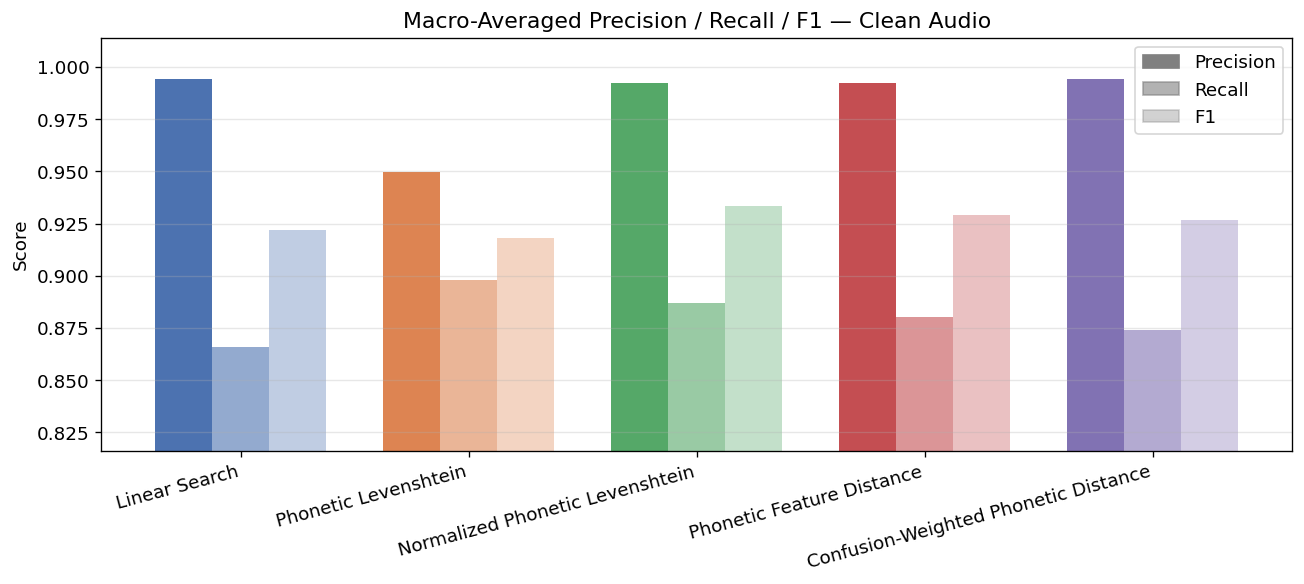

In [18]:
if clean:
    prec  = [clean[d]['macro']['precision'] for d in DETECTORS]
    rec   = [clean[d]['macro']['recall']    for d in DETECTORS]
    f1    = [clean[d]['macro']['f1']        for d in DETECTORS]

    x = np.arange(len(DETECTORS))
    w = 0.25

    all_vals = prec + rec + f1
    y_min = max(0, min(all_vals) - 0.05)
    y_max = max(all_vals) + 0.02

    import matplotlib.patches as mpatches
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, det in enumerate(DETECTORS):
        c = DET_COLOR[det]
        ax.bar(x[i] - w, prec[i], w, color=c, alpha=1.0)
        ax.bar(x[i],     rec[i],  w, color=c, alpha=0.6)
        ax.bar(x[i] + w, f1[i],   w, color=c, alpha=0.35)

    ax.legend(handles=[
        mpatches.Patch(color='grey', alpha=1.0,  label='Precision'),
        mpatches.Patch(color='grey', alpha=0.6,  label='Recall'),
        mpatches.Patch(color='grey', alpha=0.35, label='F1'),
    ])
    ax.set_xticks(x)
    ax.set_xticklabels([FULL_NAMES[d] for d in DETECTORS], rotation=15, ha='right')
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel('Score')
    ax.set_title('Macro-Averaged Precision / Recall / F1 — Clean Audio')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 2. Noise Robustness — Macro F1 Grouped by Condition

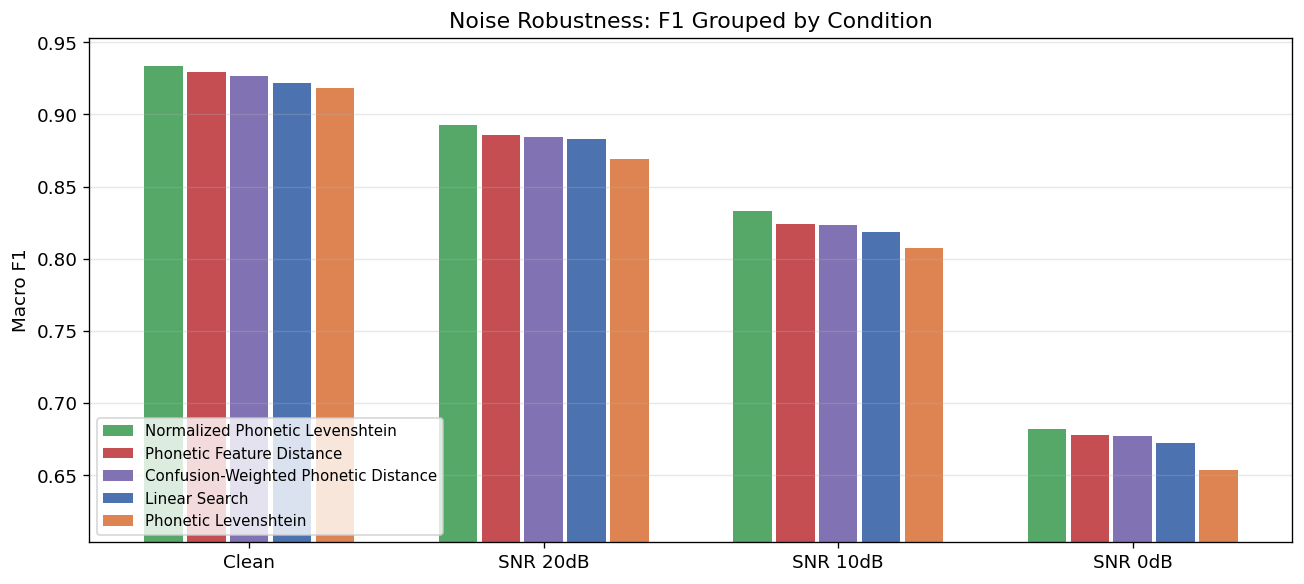

In [19]:
cond_names = list(CONDITIONS.keys())
n_det = len(DETECTORS)
w     = 0.8 / n_det

all_f1s = [CONDITIONS[c][d]['macro']['f1'] for c in cond_names for d in DETECTORS]
y_min = max(0, min(all_f1s) - 0.05)
y_max = max(all_f1s) + 0.02

fig, ax = plt.subplots(figsize=(11, 5))

x_tick_positions = []
x_tick_labels    = []
x_cursor = 0

for ci, cond in enumerate(cond_names):
    sorted_dets = sorted(DETECTORS, key=lambda d: CONDITIONS[cond][d]['macro']['f1'], reverse=True)
    group_center = x_cursor + (n_det - 1) * w / 2
    x_tick_positions.append(group_center)
    x_tick_labels.append(cond)

    for rank, det in enumerate(sorted_dets):
        f1 = CONDITIONS[cond][det]['macro']['f1']
        ax.bar(x_cursor + rank * w, f1, w * 0.9,
               color=DET_COLOR[det],
               label=FULL_NAMES[det] if ci == 0 else None)

    x_cursor += n_det * w + 0.3

ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels)
ax.set_ylim(y_min, y_max)
ax.set_ylabel('Macro F1')
ax.set_title('Noise Robustness: F1 Grouped by Condition')
ax.legend(loc='lower left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Top 3 and Bottom 3 Keywords — Clean Audio

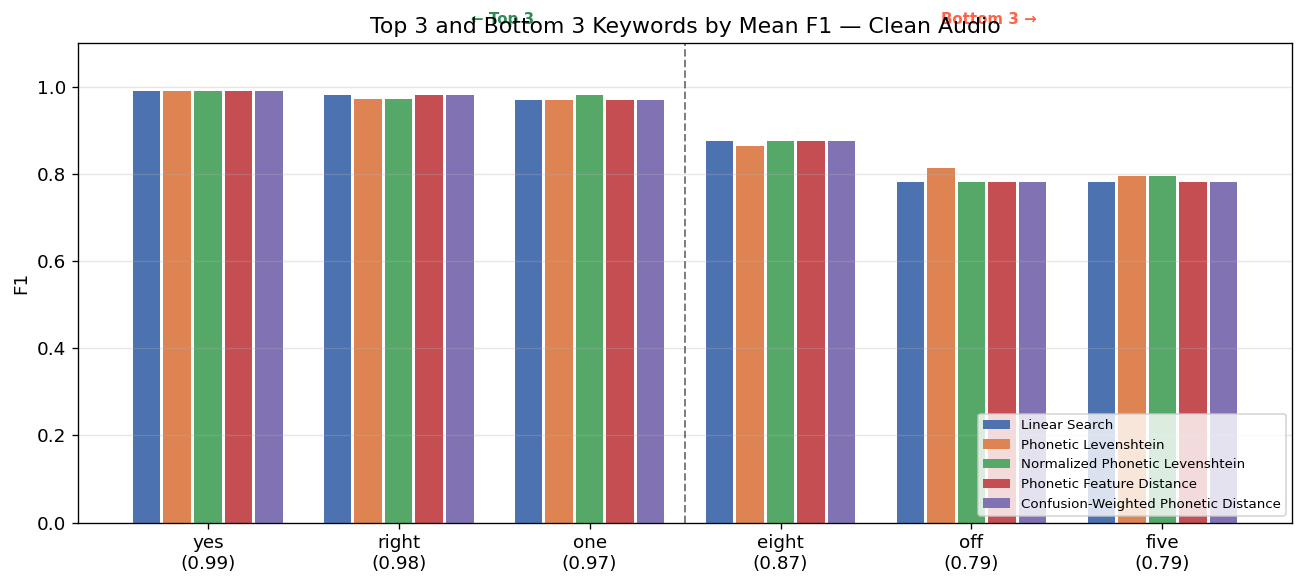

Top 3:    ['yes', 'right', 'one']
Bottom 3: ['eight', 'off', 'five']


In [20]:
if clean:
    mean_f1 = {
        kw: np.mean([clean[d]['per_keyword'][kw]['f1'] for d in DETECTORS])
        for kw in KEYWORDS
    }
    ranked  = sorted(KEYWORDS, key=lambda k: mean_f1[k], reverse=True)
    top3    = ranked[:3]
    bottom3 = ranked[-3:]
    selected = top3 + bottom3

    x = np.arange(len(selected))
    w = 0.8 / len(DETECTORS)
    offsets = np.linspace(-(len(DETECTORS)-1)/2, (len(DETECTORS)-1)/2, len(DETECTORS)) * w

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, det in enumerate(DETECTORS):
        f1s = [clean[det]['per_keyword'][kw]['f1'] for kw in selected]
        ax.bar(x + offsets[i], f1s, w * 0.9,
               color=DET_COLOR[det], label=FULL_NAMES[det])

    ax.axvline(2.5, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
    ax.text(0.35, 1.04, '← Top 3', transform=ax.transAxes, ha='center',
            color='seagreen', fontsize=9, fontweight='bold')
    ax.text(0.75, 1.04, 'Bottom 3 →', transform=ax.transAxes, ha='center',
            color='tomato', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f'{kw}\n({mean_f1[kw]:.2f})' for kw in selected],
        rotation=0, ha='center'
    )
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('F1')
    ax.set_title('Top 3 and Bottom 3 Keywords by Mean F1 — Clean Audio')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Top 3:   ', top3)
    print('Bottom 3:', bottom3)

## 4. Threshold Tuning Curves — Precision / Recall / F1 vs Threshold

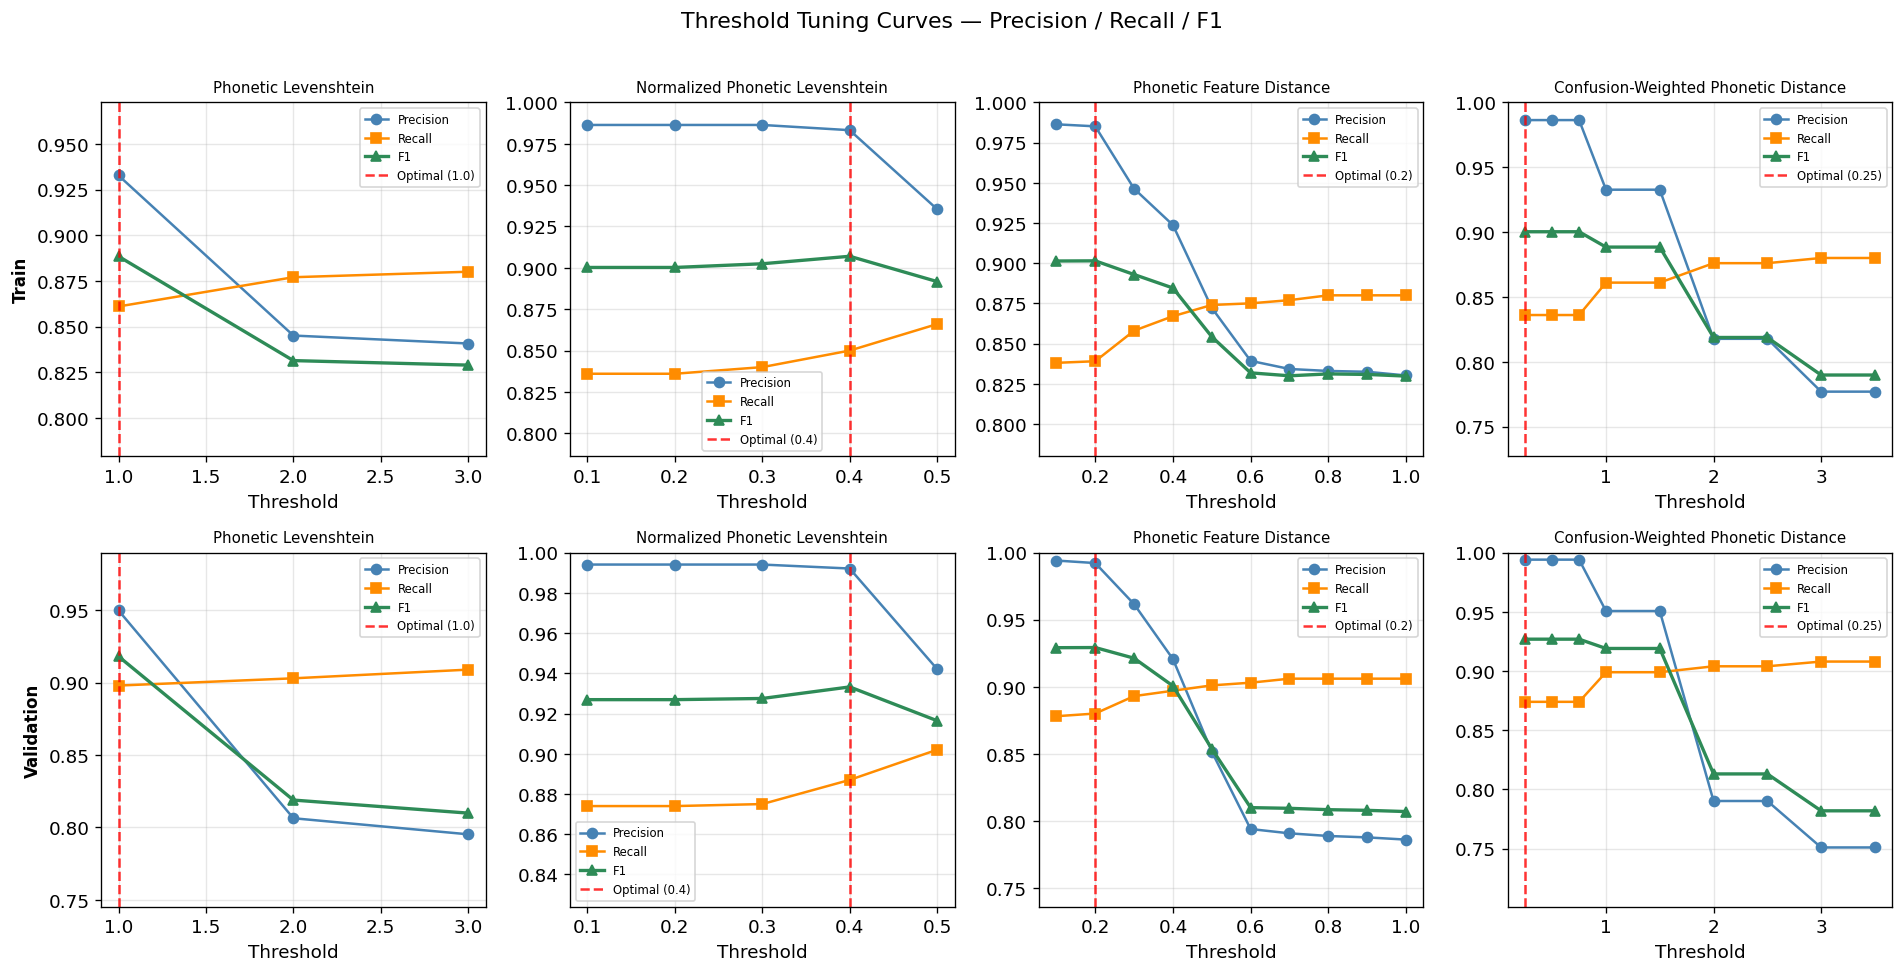

In [22]:
curves_train = load('threshold_curves.json')
curves_val   = load('threshold_curves_validation.json')
thresholds   = load('thresholds.json')

def _draw_curve_row(axes, curves, tunable, label):
    for ax, det in zip(axes, tunable):
        curve_key = next((k for k in curves if det.startswith(k.split('(')[0])), None)
        if curve_key is None or curve_key not in curves:
            ax.set_visible(False)
            continue

        curve = curves[curve_key]
        xs  = [float(k) for k in curve]
        ps  = [curve[k]['precision'] for k in curve]
        rs  = [curve[k]['recall']    for k in curve]
        f1s = [curve[k]['f1']        for k in curve]

        ax.plot(xs, ps,  'o-', color='steelblue',  label='Precision')
        ax.plot(xs, rs,  's-', color='darkorange',  label='Recall')
        ax.plot(xs, f1s, '^-', color='seagreen',    label='F1', linewidth=2)

        if thresholds:
            best_k = thresholds.get(curve_key)
            if best_k is not None:
                ax.axvline(best_k, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
                           label=f'Optimal ({best_k})')

        all_vals = ps + rs + f1s
        ax.set_ylim(max(0, min(all_vals) - 0.05), min(1.0, max(all_vals) + 0.04))
        ax.set_xlabel('Threshold')
        ax.set_title(FULL_NAMES.get(det, det), fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel(label, fontsize=10, fontweight='bold')

if curves_train:
    tunable = [d for d in DETECTORS if 'LinearSearch' not in d]
    n = len(tunable)
    n_rows = 2 if curves_val else 1

    fig, all_axes = plt.subplots(n_rows, n, figsize=(4 * n, 4 * n_rows))
    if n_rows == 1:
        all_axes = [all_axes]

    _draw_curve_row(all_axes[0], curves_train, tunable, 'Train')
    if curves_val:
        _draw_curve_row(all_axes[1], curves_val, tunable, 'Validation')

    fig.suptitle('Threshold Tuning Curves — Precision / Recall / F1', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("threshold_curves.json not found — run: uv run python -m grader.tune")